### Economic Indicators (Inputs) That Drive Rotation
##### 5 Key economic indicators signal optimal timing for sector rotations:

+ Interest Rates: Changes impact financial sector performance
+ GDP Growth: Influences cyclical sector momentum
+ Employment Data: Affects consumer-focused sectors
+ Inflation Rates: Drives commodity-related sector movement
+ Manufacturing Activity: Determines industrial sector strength

In [37]:
import os
import pandas as pd
from datetime import date, timedelta
import fredapi  
import matplotlib.pyplot as plt

In [36]:
fred = fredapi.Fred(api_key=os.getenv("FRED_API_KEY"))

### Economic Phases / Market Cycles(Outputs) That Drive Rotations
#### 4 phases: early-cycle expansion, mid-cycle growth, late-cycle peak, and recession. Each phase presents opportunities in different sectors:

+ Early-cycle sectors excel during economic recovery periods (consumer discretionary, financials, industrials)
+ Mid-cycle performers lead during steady growth periods (technology, healthcare, materials)
+ Late-cycle sectors dominate during peak economic activity (energy, utilities, staples)
+ Defensive sectors maintain stability during recessions (healthcare, utilities, consumer staples)

### Specific indicator thresholds trigger sector shifts:

+ Rising interest rates (>0.5% increase): Rotate to financials
+ Declining GDP (<2% growth): Move to defensive sectors
+ High inflation (>3%): Shift to materials energy sectors
+ Strong employment (>200k new jobs): Target consumer discretionary
+ Manufacturing expansion (PMI >55): Focus on industrials

In [20]:
date_today = date.today()
date_one_year_ago = date_today - timedelta(days=365)
#date_five_years_ago = date_today - timedelta(days=5*365)
#date_ten_years_ago = date_today - timedelta(days=10*365)


In [21]:
fred_series_ids = pd.read_csv("../data/Economic_data_tickers_FRED.csv")
fred_series_ids

,Name,Ticker,Category,Frequency
0,Secured Overnight Financing Rate,SOFR,Interest Rate,Daily
1,10-Year Treasury Constant Maturity Rate,GS10,Interest Rate,Daily
2,US AAA - OAS,BAMLC0A1CAAA,Credit Spread,Daily
3,US AA - OAS,BAMLC0A2CAA,Credit Spread,Daily
4,US A - OAS,BAMLC0A3CA,Credit Spread,Daily
5,US BBB - OAS,BAMLC0A4CBBB,Credit Spread,Daily
6,US High Yield - OAS,BAMLH0A0HYM2,Credit Spread,Daily
7,Nominal GDP,GDP,GDP,Quarterly
8,Real Gross Domestic Product,GDPC1,GDP,Quarterly
9,Headline - Consumer Price Index,CPIAUCSL,Inflation,Monthly


In [27]:
fred_data = {}
for index, row in fred_series_ids.iterrows():    
    start_date = date_one_year_ago
    print(f"Fetching data for {row['Ticker']} from {start_date} to {date_today} with frequency {row['Frequency']}")
    frequency = row['Frequency'][0].lower()
    if frequency == 'd':
        frequency = 'm'
    data = fred.get_series(row['Ticker'], observation_start=start_date, observation_end=date_today, frequency=frequency, aggregation_method='eop')
    fred_data[row['Ticker']] = data

Fetching data for SOFR from 2025-02-06 to 2026-02-06 with frequency Daily
Fetching data for GS10 from 2025-02-06 to 2026-02-06 with frequency Daily
Fetching data for BAMLC0A1CAAA from 2025-02-06 to 2026-02-06 with frequency Daily
Fetching data for BAMLC0A2CAA from 2025-02-06 to 2026-02-06 with frequency Daily
Fetching data for BAMLC0A3CA from 2025-02-06 to 2026-02-06 with frequency Daily
Fetching data for BAMLC0A4CBBB from 2025-02-06 to 2026-02-06 with frequency Daily
Fetching data for BAMLH0A0HYM2 from 2025-02-06 to 2026-02-06 with frequency Daily
Fetching data for GDP from 2025-02-06 to 2026-02-06 with frequency Quarterly
Fetching data for GDPC1 from 2025-02-06 to 2026-02-06 with frequency Quarterly
Fetching data for CPIAUCSL from 2025-02-06 to 2026-02-06 with frequency Monthly
Fetching data for CPILFESL from 2025-02-06 to 2026-02-06 with frequency Monthly
Fetching data for INDPRO from 2025-02-06 to 2026-02-06 with frequency Monthly
Fetching data for TCU from 2025-02-06 to 2026-02-06

In [29]:
fred_data_df = pd.DataFrame(fred_data)
fred_data_df.tail(10)

,SOFR,GS10,BAMLC0A1CAAA,BAMLC0A2CAA,BAMLC0A3CA,BAMLC0A4CBBB,BAMLH0A0HYM2,GDP,GDPC1,CPIAUCSL,CPILFESL,INDPRO,TCU,PAYEMS,CES0500000003,UNRATE,CIVPART
2025-05-01,4.35,4.42,0.34,0.50,0.77,1.16,3.32,NaN,NaN,320.580,326.854,100.9655,75.8894,159452.0,36.23,4.3,62.4
2025-06-01,4.45,4.38,0.35,0.49,0.73,1.08,2.96,NaN,NaN,321.500,327.600,101.4785,76.1810,159439.0,36.31,4.1,62.3
2025-07-01,4.39,4.39,0.31,0.44,0.65,0.99,2.86,31098.027,24026.834,322.132,328.656,101.8940,76.3997,159511.0,36.43,4.3,62.2
2025-08-01,4.34,4.26,0.33,0.45,0.68,1.02,2.84,NaN,NaN,323.364,329.793,101.5867,76.0770,159485.0,36.58,4.3,62.3
2025-09-01,4.24,4.12,0.31,0.43,0.63,0.97,2.80,NaN,NaN,324.368,330.542,101.7779,76.1283,159593.0,36.65,4.4,62.5
2025-10-01,4.22,4.06,0.35,0.47,0.66,1.02,2.94,NaN,NaN,NaN,NaN,101.5163,75.8411,159420.0,36.81,NaN,NaN
2025-11-01,4.12,4.09,0.34,0.49,0.67,1.05,2.92,NaN,NaN,325.031,331.068,101.9528,76.0755,159476.0,36.90,4.5,62.5
2025-12-01,3.87,4.14,0.34,0.49,0.65,1.01,2.81,NaN,NaN,326.030,331.860,102.3250,76.2615,159526.0,37.02,4.4,62.4
2026-01-01,3.68,4.21,0.33,0.46,0.61,0.95,2.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
fred_data['GDP'].tail()

2025-01-01    30042.113
2025-04-01    30485.729
2025-07-01    31098.027
dtype: float64

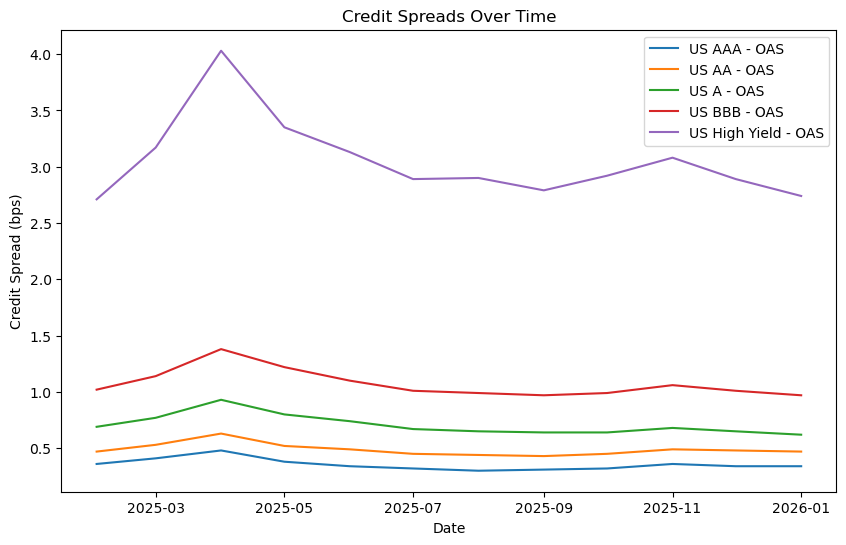

In [19]:
### Credit Spreads on 1 plot
credit_tickers = fred_series_ids[fred_series_ids['Category'] == 'Credit Spread']['Ticker'].tolist()
credit_ticker_names = fred_series_ids[fred_series_ids['Category'] == 'Credit Spread']['Name'].tolist()

plt.figure(figsize=(10, 6))
plt.plot(fred_data_df.index, fred_data_df[credit_tickers], label=credit_ticker_names)
plt.legend()
plt.title("Credit Spreads Over Time")
plt.xlabel("Date")
plt.ylabel("Credit Spread (bps)")
plt.show()

[]

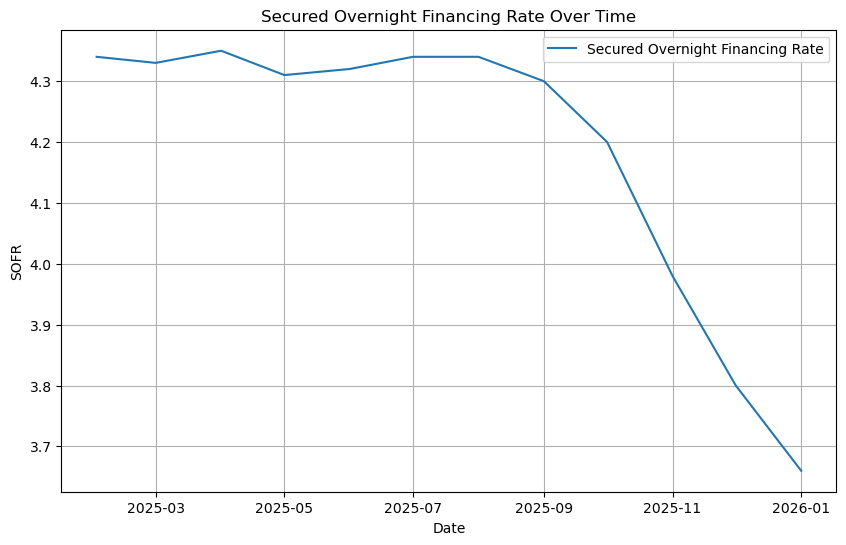

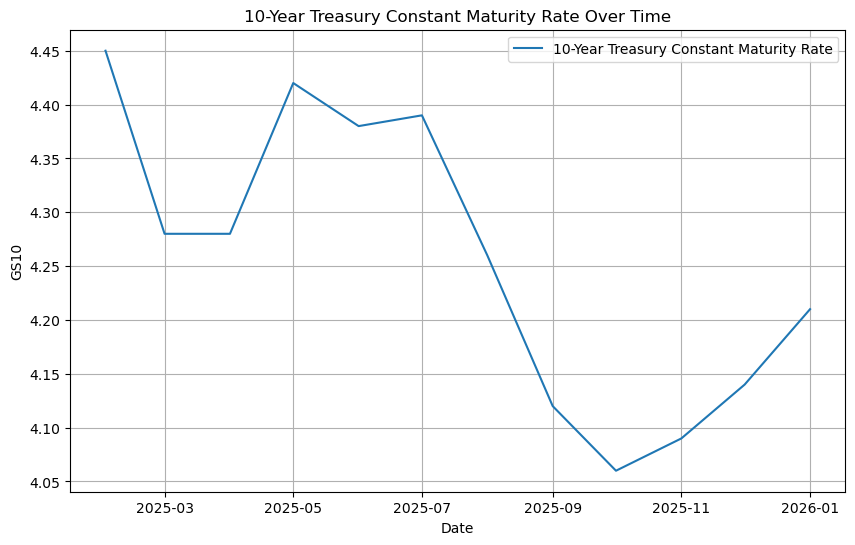

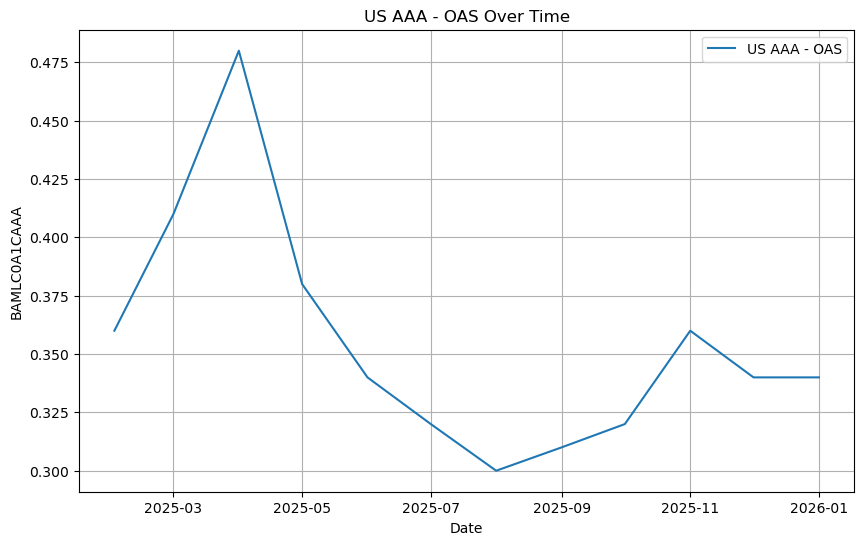

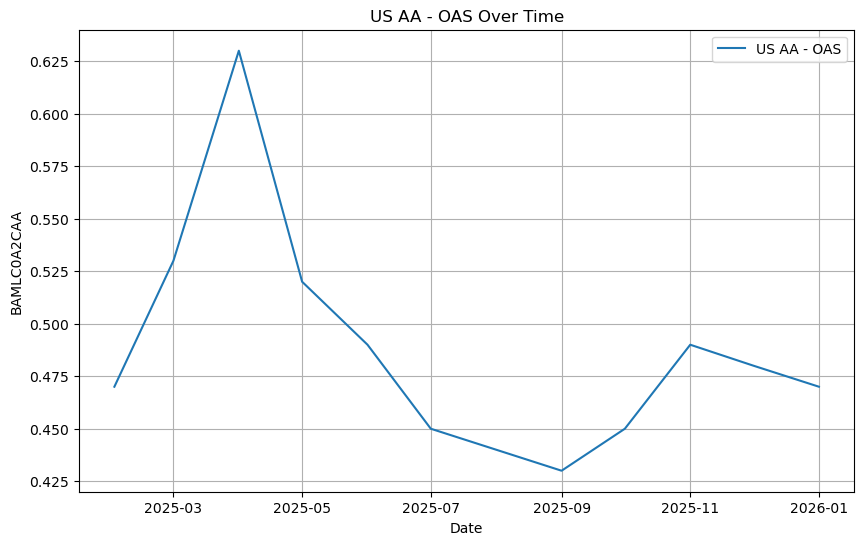

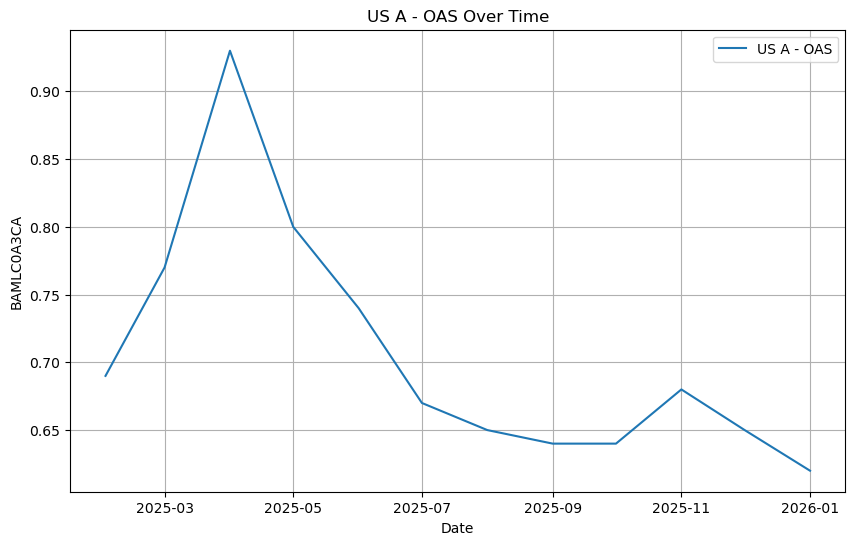

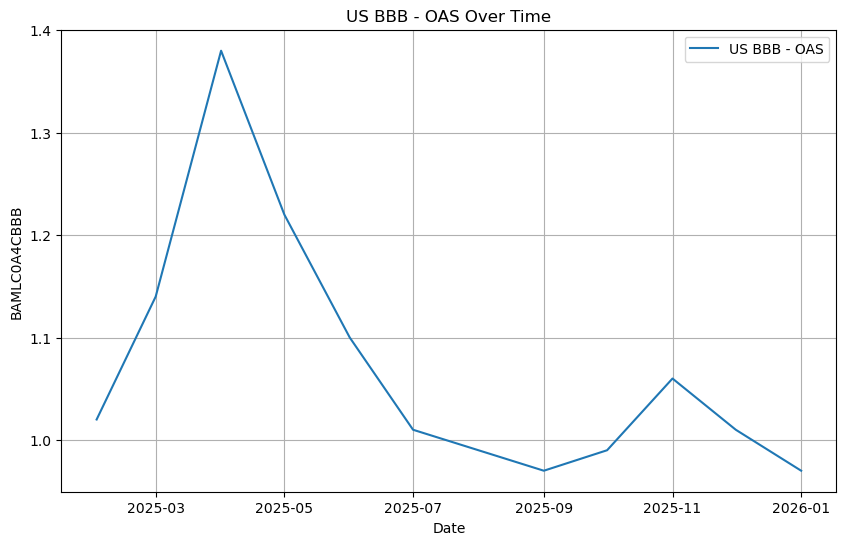

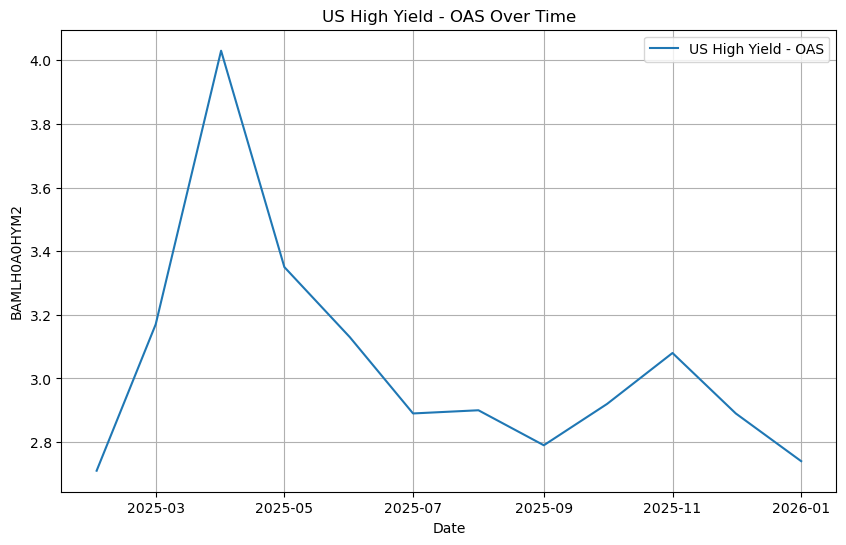

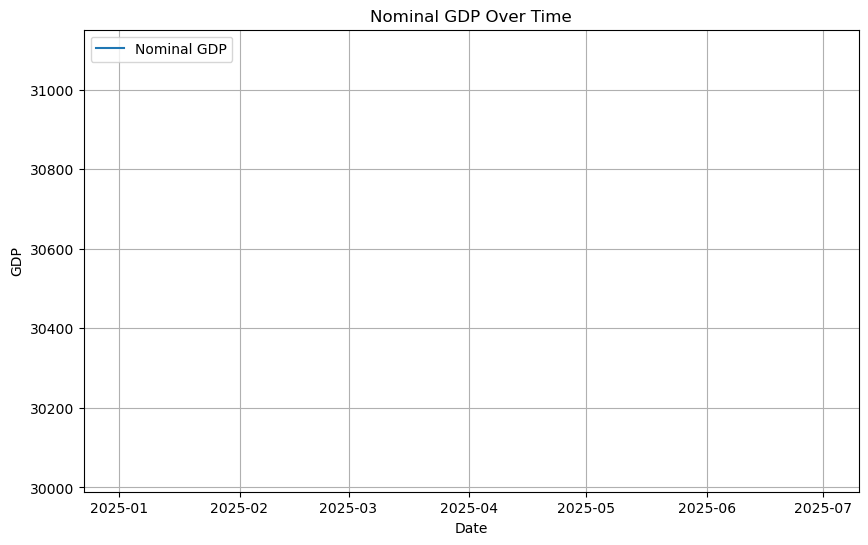

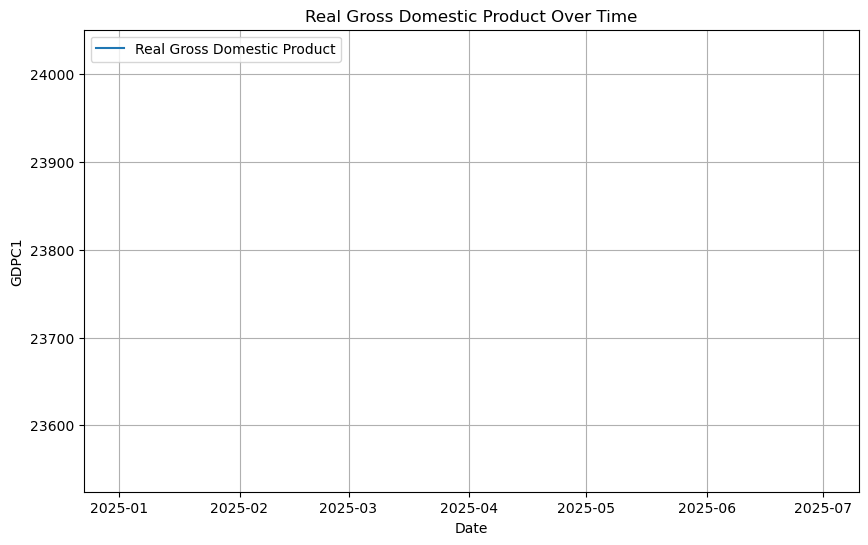

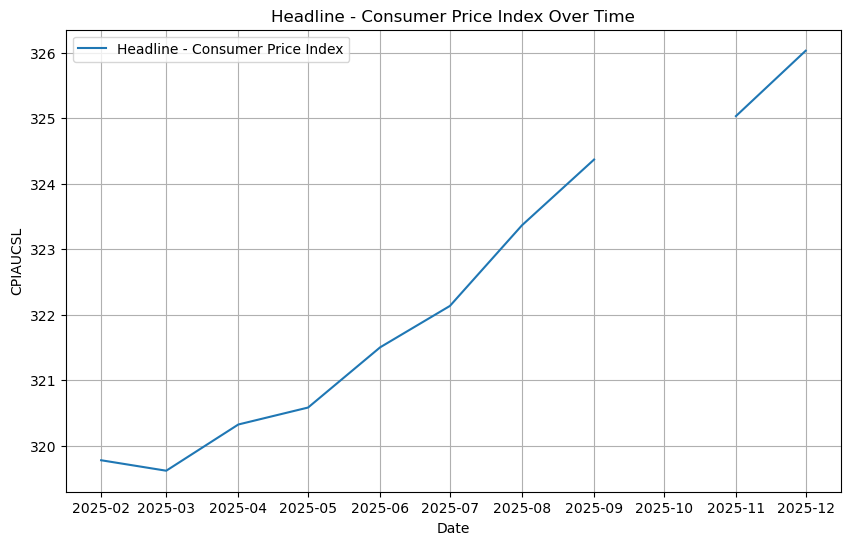

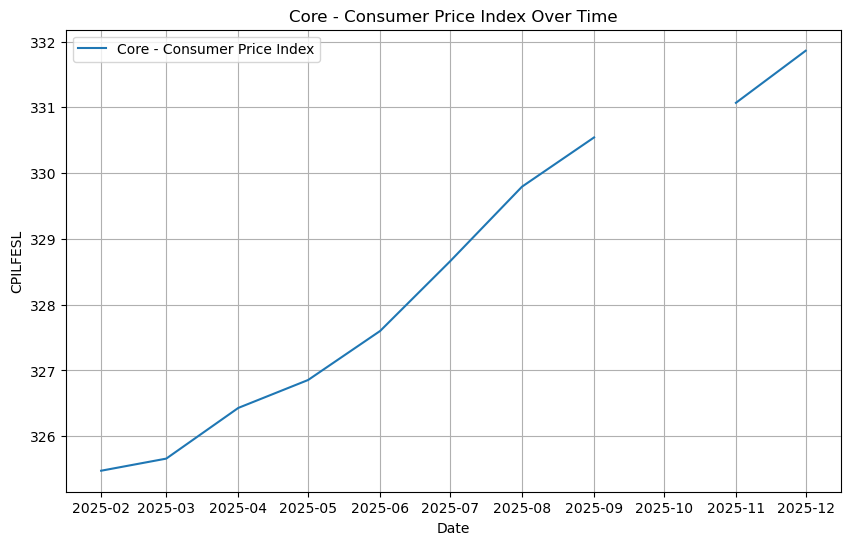

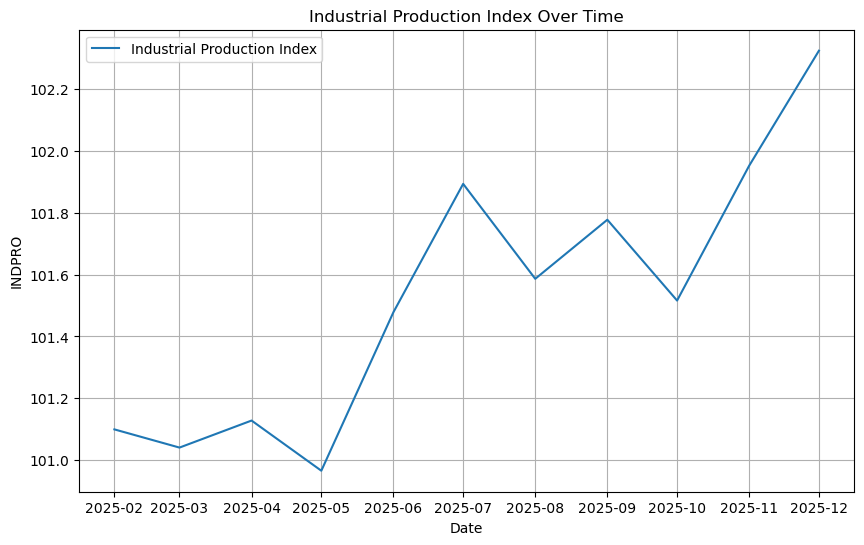

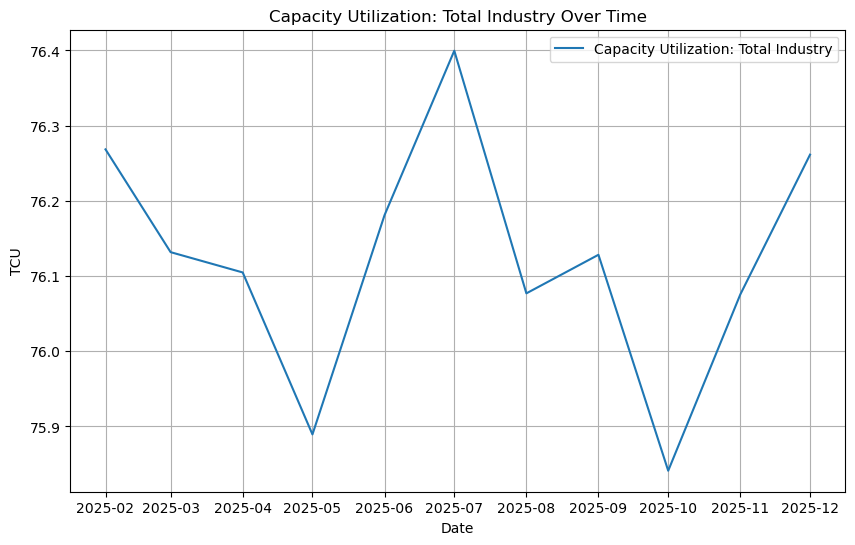

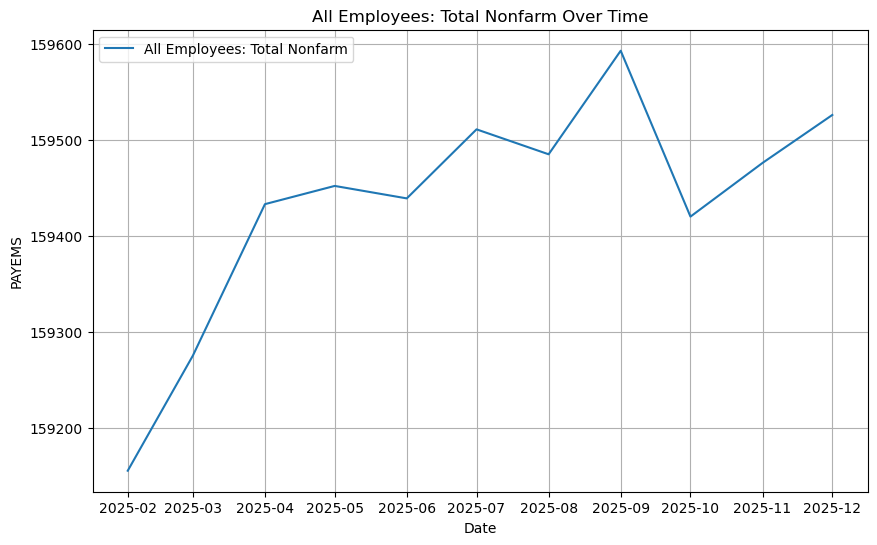

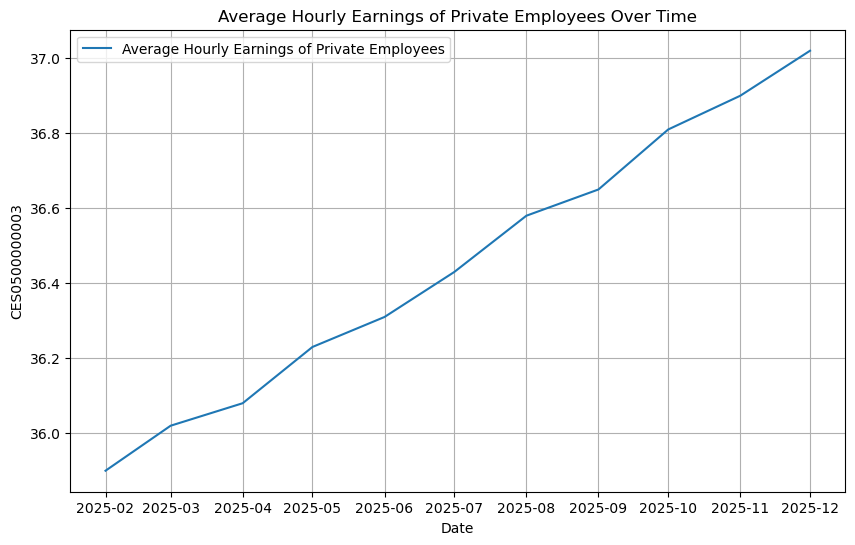

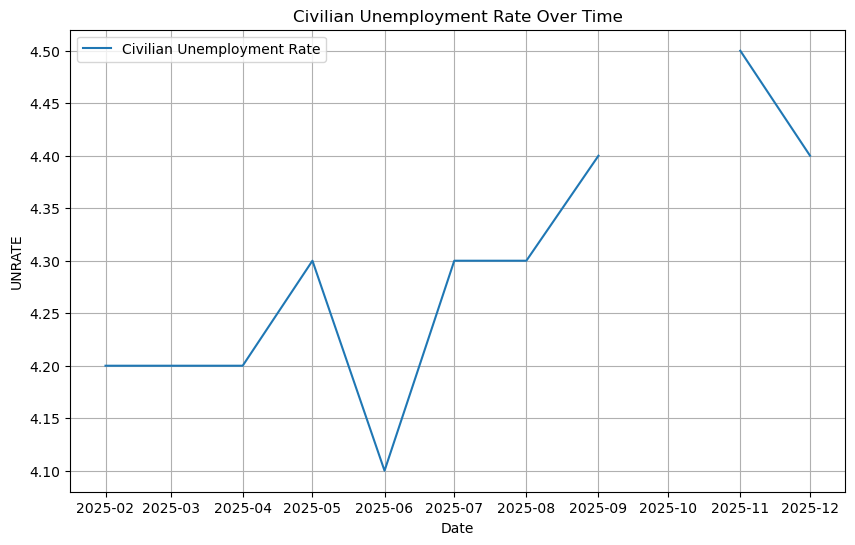

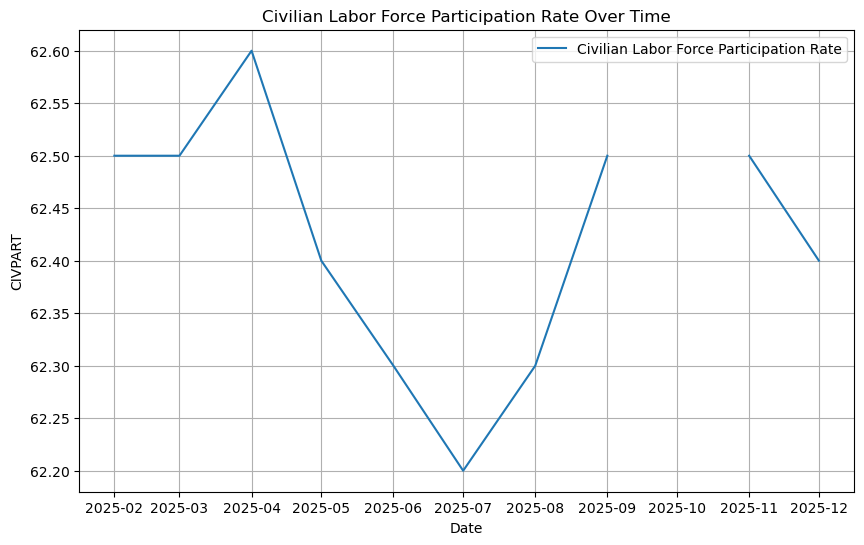

In [15]:
### Graphs for each indicator can be added below ###

tickers = fred_series_ids['Ticker'].tolist()

for ticker in tickers:
    ticker_name = fred_series_ids[fred_series_ids['Ticker'] == ticker]['Name'].values[0]
    plt.figure(figsize=(10, 6))
    plt.plot(fred_data_df.index, fred_data_df[ticker], label=ticker_name)
    plt.title(f'{ticker_name} Over Time')
    plt.xlabel('Date')
    plt.ylabel(ticker)
    plt.legend()
    plt.grid()
    plt.show()
